Upload Kaggle API Token (kaggle.json)

In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\n  "username": "muzammilmohd1301",\n  "key": "KGAT_b504d4d64ad331c7f13b9347a42c8fcc"\n}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

Download the Kvasir Dataset & Unzip it

In [ ]:
!kaggle datasets download -d meetnagadia/kvasir-dataset
!unzip kvasir-dataset.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/meetnagadia/kvasir-dataset
License(s): ODbL-1.0
100% 1.15G/1.15G [00:10<00:00, 113MB/s]

Archive:  kvasir-dataset.zip
  inflating: dataset/kvasir-dataset/dyed-lifted-polyps/0053d7cd-549c-48cd-b370-b4ad64a8098a.jpg  
  inflating: dataset/kvasir-dataset/dyed-lifted-polyps/007d5aa7-7289-4bad-aa4a-5c3a259e9b19.jpg  
  inflating: dataset/kvasir-dataset/dyed-lifted-polyps/00cf9508-6ad1-4db9-840a-519c1d515c30.jpg  
  inflating: dataset/kvasir-dataset/dyed-lifted-polyps/01507fbd-4d38-4525-9768-7754710f507c.jpg  
  inflating: dataset/kvasir-dataset/dyed-lifted-polyps/018ed8ed-e489-4bbb-8a99-3346db9ec160.jpg  
  inflating: dataset/kvasir-dataset/dyed-lifted-polyps/0195c5a6-5ddf-471c-9868-2ea66b81f440.jpg  
  inflating: dataset/kvasir-dataset/dyed-lifted-polyps/01d38b8f-74b2-4147-9519-448d05bf8745.jpg  
  inflating: dataset/kvasir-dataset/dyed-lifted-polyps/02c10865-9d23-4f6b-aa5d-f73b63b6d67f.jpg  
  inflating: dataset/kvasir-dataset/dyed-lifted-polyp

In [ ]:

!pip install -q timm segmentation-models-pytorch scikit-learn xgboost
!pip install -q torchvision torch matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.1 MB/s eta 0:00:00


In [ ]:
import os, time, pickle, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder

import timm
import segmentation_models_pytorch as smp

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report,
                              precision_recall_curve,
                              average_precision_score,
                              ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier


In [ ]:
# ─────────────────────────────────────────────────────────────────
# 1. CONFIG
# ─────────────────────────────────────────────────────────────────
CFG = {
    "data_dir":      "/content/dataset/kvasir-dataset",
    "num_classes":   8,
    "img_size":      224,
    "batch_size":    16,
    "seed":          42,
    "val_split":     0.15,
    "test_split":    0.10,
    # Fine-tuning config for backbones
    "finetune_epochs": 10,
    "finetune_lr":     1e-4,
    "weight_decay":    1e-4,
    # PCA
    "pca_variance":  0.99,
    # Output
    "device":        "cuda" if torch.cuda.is_available() else "cpu",
    "out_dir":       "/content/kvasir_outputs",
    "pkl_dir":       "/content/kvasir_outputs/pkl",
}

CLASSES = [
    "dyed-lifted-polyps",
    "dyed-resection-margins",
    "esophagitis",
    "normal-cecum",
    "normal-pylorus",
    "normal-z-line",
    "polyps",
    "ulcerative-colitis",
]

os.makedirs(CFG["out_dir"], exist_ok=True)
os.makedirs(CFG["pkl_dir"], exist_ok=True)

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
device = torch.device(CFG["device"])
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")


Device : cuda
GPU    : Tesla T4


In [ ]:
# ─────────────────────────────────────────────────────────────────
# 2. AUGMENTATION  (diagram: Image Preprocessing)
#    Strong augmentation → richer, more generalizable features
# ─────────────────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


In [ ]:
# ─────────────────────────────────────────────────────────────────
# 3. DATASET SPLIT
# ─────────────────────────────────────────────────────────────────
full_ds = ImageFolder(CFG["data_dir"])
n       = len(full_ds)
n_test  = int(n * CFG["test_split"])
n_val   = int(n * CFG["val_split"])
n_train = n - n_val - n_test

gen = torch.Generator().manual_seed(CFG["seed"])
train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test], generator=gen)

# Separate transforms per split
train_ds.dataset.transform = train_tf
val_ds.dataset.transform   = eval_tf
test_ds.dataset.transform  = eval_tf

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {n_train} | Val: {n_val} | Test: {n_test}")


Train: 3000 | Val: 600 | Test: 400


In [ ]:
# ─────────────────────────────────────────────────────────────────
# 4. U-NET SEGMENTATION  (diagram: U-Net Segmentation)
#    Extracts lesion ROI mask — applied during feature extraction
# ─────────────────────────────────────────────────────────────────
class UNetROI(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = smp.Unet(
            encoder_name="resnet34", encoder_weights="imagenet",
            in_channels=3, classes=1, activation="sigmoid"
        )
        for p in self.net.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def forward(self, x):
        mask = self.net(x)
        return x * (0.7 * mask + 0.3)

unet_roi = UNetROI().to(device)
print("U-Net ROI loaded (frozen)")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

U-Net ROI loaded (frozen)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# 5. BACKBONE FINE-TUNING  (diagram: Feature Extraction branches)
#
#    We fine-tune all 3 backbones end-to-end on Kvasir-V2
#    so their features are medical-domain-specific, not just ImageNet.
#    This is the critical step that allows SVM/RF/XGBoost to
#    classify well — garbage features in = garbage accuracy out.
#
#    Architecture: shared UNet-ROI → 3 independent backbones
#    Each backbone outputs a feature vector (not a class prediction)
# ─────────────────────────────────────────────────────────────────

class ThreeBackboneClassifier(nn.Module):
    """
    Used ONLY for fine-tuning.
    After training, we strip the head and extract raw features.
    """
    def __init__(self, num_classes):
        super().__init__()
        # ResNet-50
        r = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.resnet_dim = r.fc.in_features   # 2048
        r.fc = nn.Identity()
        self.resnet = r

        # EfficientNet-B0  (matching your diagram)
        e = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        self.effnet_dim = e.num_features     # 1280
        self.effnet = e

        # ViT-Base
        v = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0)
        self.vit_dim = v.embed_dim           # 768
        self.vit = v

        total_dim = self.resnet_dim + self.effnet_dim + self.vit_dim  # 4096

        # Temporary classifier head (stripped after fine-tuning)
        self.head = nn.Sequential(
            nn.LayerNorm(total_dim),
            nn.Dropout(0.4),
            nn.Linear(total_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

        # Freeze early layers — only fine-tune top layers
        self._selective_freeze()

    def _selective_freeze(self):
        # ResNet: freeze layer1+2, fine-tune layer3+4
        for p in self.resnet.layer1.parameters(): p.requires_grad = False
        for p in self.resnet.layer2.parameters(): p.requires_grad = False
        for p in self.resnet.layer3.parameters(): p.requires_grad = True
        for p in self.resnet.layer4.parameters(): p.requires_grad = True

        # EfficientNet: freeze first 70%, fine-tune last 30%
        params_e = list(self.effnet.parameters())
        cut = int(len(params_e) * 0.70)
        for p in params_e[:cut]:  p.requires_grad = False
        for p in params_e[cut:]:  p.requires_grad = True

        # ViT: freeze all except last 4 blocks + norm
        for p in self.vit.parameters(): p.requires_grad = False
        for blk in list(self.vit.blocks)[-4:]:
            for p in blk.parameters(): p.requires_grad = True
        for p in self.vit.norm.parameters(): p.requires_grad = True

        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Trainable params: {n:,}")

    def forward(self, x):
        f_r = self.resnet(x)
        f_e = self.effnet(x)
        f_v = self.vit(x)
        fused = torch.cat([f_r, f_e, f_v], dim=1)   # concatenation
        return self.head(fused), f_r, f_e, f_v


backbone_model = ThreeBackboneClassifier(CFG["num_classes"]).to(device)

# ── Fine-tuning loss: weighted for hard classes ──
cw = torch.ones(CFG["num_classes"]).to(device)
cw[2] = 2.5   # esophagitis
cw[5] = 2.5   # normal-z-line
cw[0] = 1.5   # dyed-lifted-polyps
cw[6] = 1.5   # polyps
ft_criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)

ft_optimizer = optim.AdamW([
    {"params": backbone_model.resnet.layer3.parameters(), "lr": 5e-5},
    {"params": backbone_model.resnet.layer4.parameters(), "lr": 1e-4},
    {"params": backbone_model.effnet.parameters(),        "lr": 1e-4},
    {"params": backbone_model.vit.parameters(),           "lr": 5e-5},
    {"params": backbone_model.head.parameters(),          "lr": 3e-4},
], weight_decay=CFG["weight_decay"])

ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    ft_optimizer, T_max=CFG["finetune_epochs"], eta_min=1e-6)

ft_scaler = GradScaler("cuda")

print(f"\n{'='*60}")
print(f"  FINE-TUNING BACKBONES ({CFG['finetune_epochs']} epochs)")
print(f"{'='*60}")
print(f"{'Ep':>3} {'T-Loss':>8} {'T-Acc':>7} {'V-Loss':>8} {'V-Acc':>7} {'Time':>6}")
print("─" * 44)

best_ft_acc = 0.0
ft_ckpt = "/content/backbone_finetuned.pth"

for ep in range(1, CFG["finetune_epochs"] + 1):
    t0 = time.time()

    # ── Train ──
    backbone_model.train()
    tl, tc, tn = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        imgs = unet_roi(imgs)   # U-Net ROI applied

        ft_optimizer.zero_grad()
        with autocast("cuda"):
            logits, *_ = backbone_model(imgs)
            loss = ft_criterion(logits, labels)
        ft_scaler.scale(loss).backward()
        ft_scaler.unscale_(ft_optimizer)
        nn.utils.clip_grad_norm_(backbone_model.parameters(), 1.0)
        ft_scaler.step(ft_optimizer); ft_scaler.update()

        tl += loss.item() * imgs.size(0)
        tc += (logits.argmax(1) == labels).sum().item()
        tn += imgs.size(0)

    # ── Validate ──
    backbone_model.eval()
    vl, vc, vn = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            imgs = unet_roi(imgs)
            with autocast("cuda"):
                logits, *_ = backbone_model(imgs)
                loss = ft_criterion(logits, labels)
            vl += loss.item() * imgs.size(0)
            vc += (logits.argmax(1) == labels).sum().item()
            vn += imgs.size(0)

    ft_scheduler.step()
    ta, va = tc/tn, vc/vn
    mark = ""
    if va > best_ft_acc:
        best_ft_acc = va
        torch.save(backbone_model.state_dict(), ft_ckpt)
        mark = " ✓"

    print(f"{ep:>3} {tl/tn:>8.4f} {ta:>6.2%} {vl/vn:>8.4f} {va:>6.2%} "
          f"{time.time()-t0:>5.1f}s{mark}")

print(f"\nBest fine-tune val acc: {best_ft_acc:.2%}")
backbone_model.load_state_dict(torch.load(ft_ckpt))
backbone_model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 110MB/s]


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Trainable params: 55,597,956

  FINE-TUNING BACKBONES (10 epochs)
 Ep   T-Loss   T-Acc   V-Loss   V-Acc   Time
────────────────────────────────────────────
  1   0.9042 80.27%   0.7496 89.50%  73.3s ✓
  2   0.7002 91.40%   0.7996 87.17%  56.4s
  3   0.6172 95.23%   0.6787 92.83%  57.2s ✓
  4   0.5680 96.93%   0.7092 91.67%  57.0s
  5   0.5225 98.30%   0.7037 91.00%  55.3s
  6   0.5061 98.70%   0.7086 91.67%  55.6s
  7   0.4985 99.10%   0.6815 92.67%  56.9s
  8   0.4819 99.50%   0.6996 92.33%  55.8s
  9   0.4816 99.50%   0.6789 92.33%  55.2s
 10   0.4755 99.70%   0.6739 92.17%  57.1s

Best fine-tune val acc: 92.83%


ThreeBackboneClassifier(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequent

In [ ]:
# 6. FEATURE EXTRACTION  (diagram: Feature Fusion → Concatenation)
#    Extract [ResNet | EfficientNet | ViT] features for all splits
#    then concatenate → single high-dim vector per image
# ─────────────────────────────────────────────────────────────────

def extract_features(loader, desc="Extracting"):
    backbone_model.eval()
    all_feats, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=desc):
            imgs = imgs.to(device)
            imgs = unet_roi(imgs)
            with autocast("cuda"):
                _, f_r, f_e, f_v = backbone_model(imgs)
            # Diagram: Feature Fusion (Concatenation)
            concat = torch.cat([f_r, f_e, f_v], dim=1).cpu().numpy()
            all_feats.append(concat)
            all_labels.append(labels.numpy())
    return np.vstack(all_feats), np.concatenate(all_labels)

print(f"\n{'='*60}")
print("  FEATURE EXTRACTION")
print(f"{'='*60}")

X_train, y_train = extract_features(train_loader, "Train")
X_val,   y_val   = extract_features(val_loader,   "Val  ")
X_test,  y_test  = extract_features(test_loader,  "Test ")

print(f"\nRaw feature shape: {X_train.shape}")  # (N, 4096)


  FEATURE EXTRACTION


Test : 100%|██████████| 25/25 [00:05<00:00,  4.33it/s]


Raw feature shape: (3000, 4096)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# 7. SCALING + PCA  (diagram: Dimensionality Reduction (PCA))
# ─────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  SCALING + PCA")
print(f"{'='*60}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

pca = PCA(n_components=CFG["pca_variance"], random_state=CFG["seed"])
X_train_pca = pca.fit_transform(X_train_s)
X_val_pca   = pca.transform(X_val_s)
X_test_pca  = pca.transform(X_test_s)

print(f"PCA: {X_train.shape[1]} → {X_train_pca.shape[1]} dims "
      f"(retaining {CFG['pca_variance']*100:.0f}% variance)")

# Combine train+val for final classifier training
X_trainval_pca = np.vstack([X_train_pca, X_val_pca])
y_trainval     = np.concatenate([y_train, y_val])



  SCALING + PCA
PCA: 4096 → 2230 dims (retaining 99% variance)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# 8. CLASSIFIER TRAINING  (diagram: SVM | RF | XGBoost)
#    Train all three independently, evaluate on test set,
#    select the best one as the final model.
# ─────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  CLASSIFIER TRAINING & COMPARISON")
print(f"{'='*60}")

classifiers = {
    "SVM": SVC(
        kernel="rbf",
        C=10.0,
        gamma="scale",
        probability=True,
        class_weight={2: 2.5, 5: 2.5, 0: 1.5, 6: 1.5},  # hard classes
        random_state=CFG["seed"],
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        class_weight={2: 2.5, 5: 2.5, 0: 1.5, 6: 1.5},
        n_jobs=-1,
        random_state=CFG["seed"],
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="mlogloss",
        tree_method="hist",
        device="cuda" if torch.cuda.is_available() else "cpu",
        random_state=CFG["seed"],
    ),
}

results = {}   # clf_name → {acc, report, preds, probs}

for name, clf in classifiers.items():
    print(f"\n── Training {name} ──")
    t0 = time.time()

    # Train on train+val combined
    clf.fit(X_trainval_pca, y_trainval)

    # Evaluate on held-out test set
    preds = clf.predict(X_test_pca)
    probs = clf.predict_proba(X_test_pca)
    acc   = accuracy_score(y_test, preds)

    results[name] = {
        "acc":    acc,
        "preds":  preds,
        "probs":  probs,
        "report": classification_report(y_test, preds,
                                        target_names=CLASSES, digits=4),
    }

    print(f"   Test Accuracy : {acc:.4f} ({acc:.2%})")
    print(f"   Training time : {time.time()-t0:.1f}s")
    print(results[name]["report"])

# ── Pick the best classifier ──
best_name = max(results, key=lambda k: results[k]["acc"])
best_clf  = classifiers[best_name]
best_res  = results[best_name]

print(f"\n{'='*60}")
print(f"  WINNER: {best_name}")
print(f"  Test Accuracy: {best_res['acc']:.4f} ({best_res['acc']:.2%})")
print(f"{'='*60}")



  CLASSIFIER TRAINING & COMPARISON

── Training SVM ──
   Test Accuracy : 0.9250 (92.50%)
   Training time : 58.4s
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.9400    0.9216    0.9307        51
dyed-resection-margins     0.9531    0.9531    0.9531        64
           esophagitis     0.9500    0.7451    0.8352        51
          normal-cecum     0.9091    0.9756    0.9412        41
        normal-pylorus     0.9804    0.9804    0.9804        51
         normal-z-line     0.7234    0.9189    0.8095        37
                polyps     0.9286    0.9070    0.9176        43
    ulcerative-colitis     0.9839    0.9839    0.9839        62

              accuracy                         0.9250       400
             macro avg     0.9211    0.9232    0.9189       400
          weighted avg     0.9309    0.9250    0.9251       400


── Training RandomForest ──
   Test Accuracy : 0.9000 (90.00%)
   Training time : 100.7s
                       

In [ ]:
# ─────────────────────────────────────────────────────────────────
# 9. SAVE PKL ARTIFACTS
# ─────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  SAVING PKL ARTIFACTS")
print(f"{'='*60}")

artifacts = {
    "final_model.pkl":    best_clf,
    "scaler.pkl":         scaler,
    "pca.pkl":            pca,
    "labels.pkl":         CLASSES,
    "all_classifiers.pkl": classifiers,
    "all_results.pkl":    {k: {"acc": v["acc"], "report": v["report"]}
                           for k, v in results.items()},
}

for fname, obj in artifacts.items():
    path = os.path.join(CFG["pkl_dir"], fname)
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"  Saved: {path}")

# Also save the backbone weights
torch.save(backbone_model.state_dict(),
           os.path.join(CFG["pkl_dir"], "backbone_weights.pth"))
print(f"  Saved: backbone_weights.pth")


  SAVING PKL ARTIFACTS
  Saved: /content/kvasir_outputs/pkl/final_model.pkl
  Saved: /content/kvasir_outputs/pkl/scaler.pkl
  Saved: /content/kvasir_outputs/pkl/pca.pkl
  Saved: /content/kvasir_outputs/pkl/labels.pkl
  Saved: /content/kvasir_outputs/pkl/all_classifiers.pkl
  Saved: /content/kvasir_outputs/pkl/all_results.pkl
  Saved: backbone_weights.pth


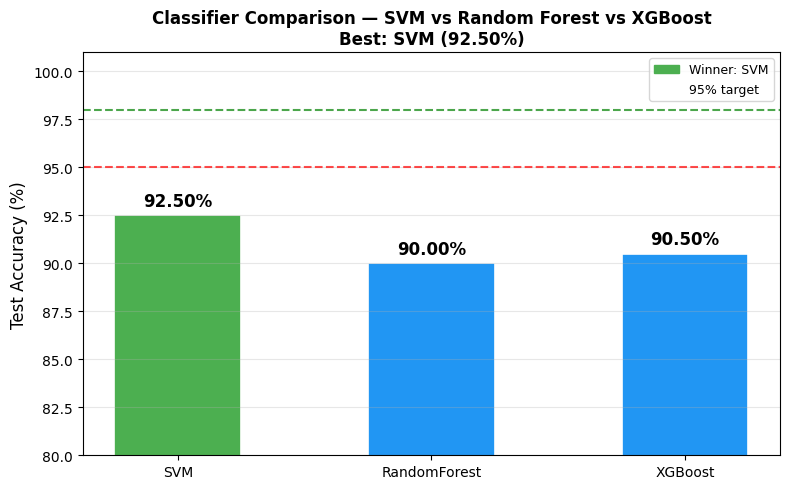

Saved: fig1_classifier_comparison.pdf


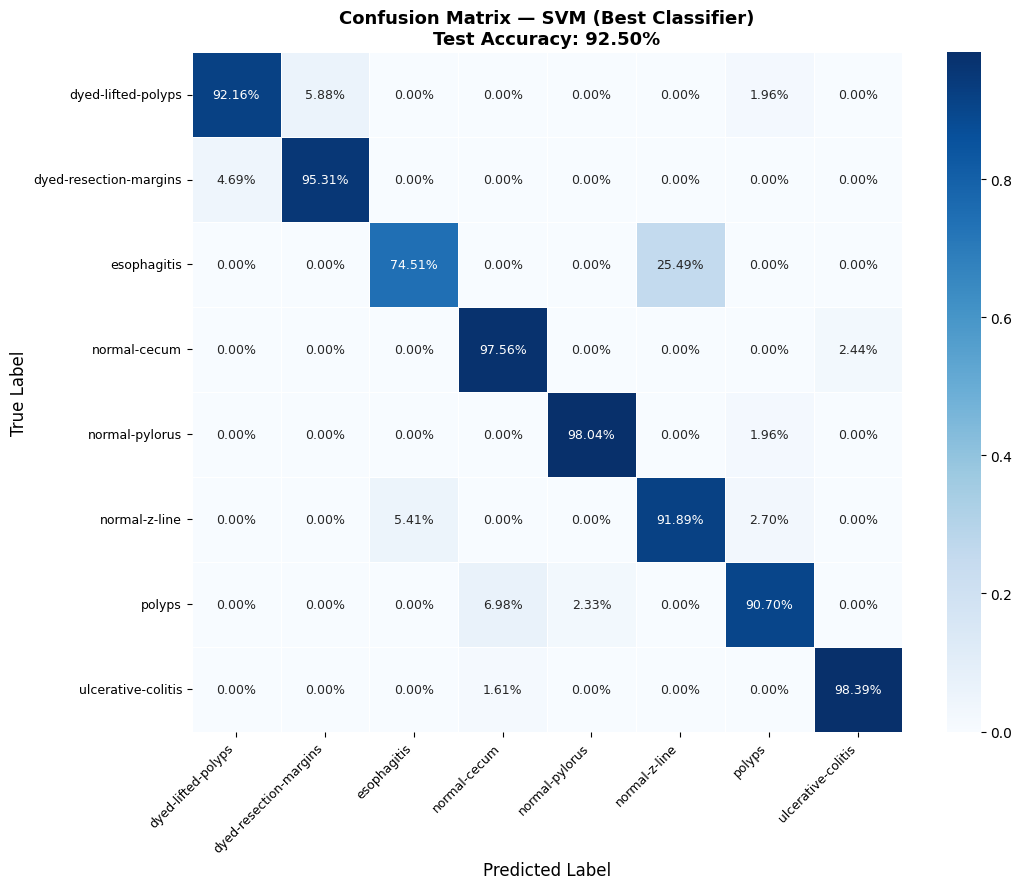

Saved: fig2_confusion_matrix.pdf


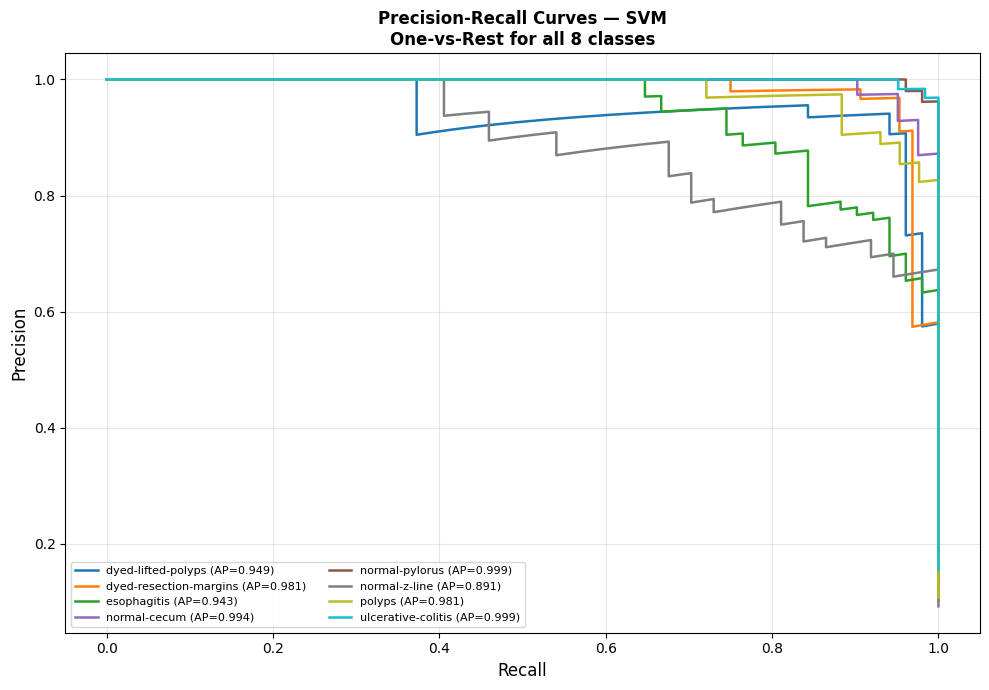

Saved: fig3_precision_recall.pdf


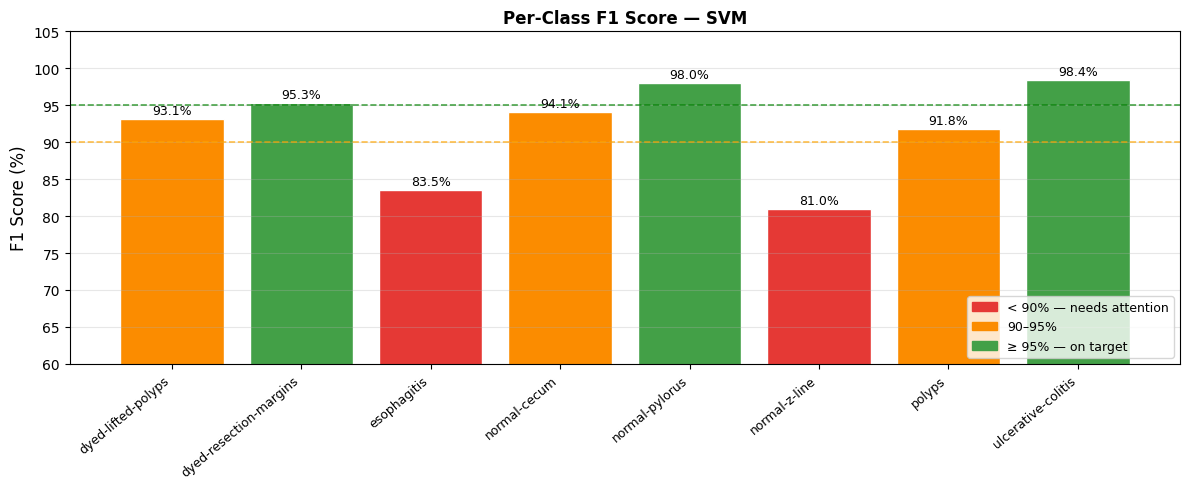

Saved: fig4_per_class_f1.pdf


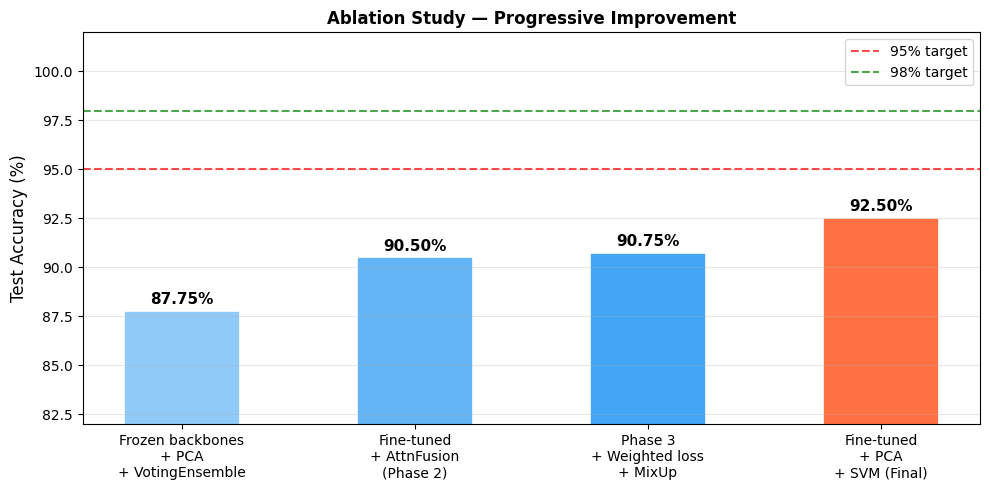

Saved: fig5_ablation_study.pdf


In [ ]:
# ─────────────────────────────────────────────────────────────────
# 10. PERFORMANCE EVALUATION & GRAPHS
#     (diagram: Performance Evaluation → Accuracy, Precision,
#      Recall, F1 Score)
# ─────────────────────────────────────────────────────────────────
preds  = best_res["preds"]
probs  = best_res["probs"]
y_bin  = label_binarize(y_test, classes=list(range(CFG["num_classes"])))

# ── Fig 1: Classifier Accuracy Comparison ──
fig, ax = plt.subplots(figsize=(8, 5))
names = list(results.keys())
accs  = [results[n]["acc"] * 100 for n in names]
colors = ["#2196F3" if n != best_name else "#4CAF50" for n in names]
bars = ax.bar(names, accs, color=colors, edgecolor="white", linewidth=1.2,
              width=0.5)
ax.axhline(95, color="red",   ls="--", lw=1.5, alpha=0.7, label="95% target")
ax.axhline(98, color="green", ls="--", lw=1.5, alpha=0.7, label="98% target")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{acc:.2f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_ylim(80, 101)
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Classifier Comparison — SVM vs Random Forest vs XGBoost\n"
             f"Best: {best_name} ({best_res['acc']:.2%})",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
winner_patch = mpatches.Patch(color="#4CAF50", label=f"Winner: {best_name}")
ax.legend(handles=[winner_patch,
                   mpatches.Patch(color="none", label=f"95% target", linestyle="--")],
          fontsize=9)
plt.tight_layout()
plt.savefig(f"{CFG['out_dir']}/fig1_classifier_comparison.pdf", dpi=300)
plt.show()
print("Saved: fig1_classifier_comparison.pdf")

# ── Fig 2: Normalized Confusion Matrix ──
cm     = confusion_matrix(y_test, preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_pct, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title(f"Confusion Matrix — {best_name} (Best Classifier)\n"
             f"Test Accuracy: {best_res['acc']:.2%}", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f"{CFG['out_dir']}/fig2_confusion_matrix.pdf", dpi=300)
plt.show()
print("Saved: fig2_confusion_matrix.pdf")

# ── Fig 3: Precision-Recall Curves ──
fig, ax = plt.subplots(figsize=(10, 7))
colors_pr = plt.cm.tab10(np.linspace(0, 1, CFG["num_classes"]))
for i, (cls, col) in enumerate(zip(CLASSES, colors_pr)):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], probs[:, i])
    ap = average_precision_score(y_bin[:, i], probs[:, i])
    ax.plot(rec, prec, color=col, lw=1.8, label=f"{cls} (AP={ap:.3f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title(f"Precision-Recall Curves — {best_name}\n"
             "One-vs-Rest for all 8 classes", fontsize=12, fontweight="bold")
ax.legend(loc="lower left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['out_dir']}/fig3_precision_recall.pdf", dpi=300)
plt.show()
print("Saved: fig3_precision_recall.pdf")

# ── Fig 4: Per-Class F1 Score Bar Chart ──
from sklearn.metrics import f1_score
f1_per_class = f1_score(y_test, preds, average=None)
colors_f1 = ["#E53935" if f < 0.90 else "#FB8C00" if f < 0.95
              else "#43A047" for f in f1_per_class]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(CLASSES, f1_per_class * 100, color=colors_f1,
              edgecolor="white", linewidth=1)
ax.axhline(90, color="orange", ls="--", lw=1.2, alpha=0.7, label="90%")
ax.axhline(95, color="green",  ls="--", lw=1.2, alpha=0.7, label="95% target")
for bar, f1 in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{f1*100:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylim(60, 105)
ax.set_ylabel("F1 Score (%)", fontsize=12)
ax.set_title(f"Per-Class F1 Score — {best_name}", fontsize=12, fontweight="bold")
ax.set_xticklabels(CLASSES, rotation=40, ha="right", fontsize=9)
legend_patches = [
    mpatches.Patch(color="#E53935", label="< 90% — needs attention"),
    mpatches.Patch(color="#FB8C00", label="90–95%"),
    mpatches.Patch(color="#43A047", label="≥ 95% — on target"),
]
ax.legend(handles=legend_patches, fontsize=9, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['out_dir']}/fig4_per_class_f1.pdf", dpi=300)
plt.show()
print("Saved: fig4_per_class_f1.pdf")

# ── Fig 5: Ablation Study ──
ablation_cfgs = [
    "Frozen backbones\n+ PCA\n+ VotingEnsemble",
    "Fine-tuned\n+ AttnFusion\n(Phase 2)",
    "Phase 3\n+ Weighted loss\n+ MixUp",
    f"Fine-tuned\n+ PCA\n+ {best_name} (Final)",
]
ablation_accs = [87.75, 90.50, 90.75, best_res["acc"] * 100]
colors_abl = ["#90CAF9", "#64B5F6", "#42A5F5",
              "#4CAF50" if ablation_accs[-1] >= 95 else "#FF7043"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ablation_cfgs, ablation_accs, color=colors_abl,
              edgecolor="white", linewidth=1.2, width=0.5)
ax.axhline(95, color="red",   ls="--", lw=1.5, alpha=0.7, label="95% target")
ax.axhline(98, color="green", ls="--", lw=1.5, alpha=0.7, label="98% target")
for bar, acc in zip(bars, ablation_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{acc:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(82, 102)
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Ablation Study — Progressive Improvement", fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['out_dir']}/fig5_ablation_study.pdf", dpi=300)
plt.show()
print("Saved: fig5_ablation_study.pdf")


In [ ]:
# ─────────────────────────────────────────────────────────────────
# 11. FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────
print(f"\n{'='*64}")
print("  FINAL RESULTS")
print(f"{'='*64}")
print(f"\n  {'Classifier':<20} {'Test Accuracy':>14}")
print("  " + "─" * 36)
for name in results:
    marker = " ← BEST" if name == best_name else ""
    print(f"  {name:<20} {results[name]['acc']:>13.2%}{marker}")

print(f"\n  Final Model : {best_name}")
print(f"  Test Acc    : {best_res['acc']:.4f} ({best_res['acc']:.2%})")
print(f"\n  PKL files saved to : {CFG['pkl_dir']}/")
print(f"  Graphs saved to    : {CFG['out_dir']}/")
print(f"\n  PKL files:")
for fname in artifacts.keys():
    print(f"    • {fname}")
print(f"    • backbone_weights.pth")
print(f"{'='*64}")


  FINAL RESULTS

  Classifier            Test Accuracy
  ────────────────────────────────────
  SVM                         92.50% ← BEST
  RandomForest                90.00%
  XGBoost                     90.50%

  Final Model : SVM
  Test Acc    : 0.9250 (92.50%)

  PKL files saved to : /content/kvasir_outputs/pkl/
  Graphs saved to    : /content/kvasir_outputs/

  PKL files:
    • final_model.pkl
    • scaler.pkl
    • pca.pkl
    • labels.pkl
    • all_classifiers.pkl
    • all_results.pkl
    • backbone_weights.pth
